# 第2弾: ブレイクアウト + ATRフィルタ戦略

## 戦略概要
- **ブレイクアウト戦略**: 直近N期間の最高値/最安値を突破したらトレンド発生とみなしてエントリー
- **ATR（Average True Range）フィルタ**: ボラティリティが一定以上のときだけエントリーを許可し、低ボラ期のダマシを除外
- 第1弾のミーンリバージョン（逆張り）とは真逆の順張り戦略

## エントリー / エグジット条件

| 方向 | エントリー条件 | エグジット条件 |
|------|--------------|--------------|
| ロング | 終値 > N期間最高値 かつ ATR > ATR長期平均 | N/2期間の最安値を下回る |
| ショート | 終値 < N期間最安値 かつ ATR > ATR長期平均 | N/2期間の最高値を上回る |

## 検証対象
- USD/JPY（FX）, ETH/JPY（暗号資産）-- 5分足

## 1. セットアップ

In [1]:
!pip install japanize-matplotlib -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 49.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [2]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

import japanize_matplotlib

print("ライブラリ読み込み完了")

ライブラリ読み込み完了


## 2. GMO Coin KLine API からデータ取得

FX用と暗号資産用でAPIエンドポイントが異なる点に注意。

In [3]:
ENDPOINTS = {
    "fx":     "https://forex-api.coin.z.com/public/v1/klines",
    "crypto": "https://api.coin.z.com/public/v1/klines",
}

SYMBOL_CONFIG = {
    "USD_JPY": {"api": "fx",     "priceType": "BID"},
    "ETH_JPY": {"api": "crypto", "priceType": None},
}

def fetch_gmo_kline(symbol, interval="5min", days_back=365):
    config = SYMBOL_CONFIG.get(symbol)
    if config is None:
        print(f"未定義のシンボル: {symbol}")
        return pd.DataFrame()

    base_url = ENDPOINTS[config["api"]]
    all_data = []
    end_date = datetime.now()
    start_date = end_date - timedelta(days=days_back)
    current_date = start_date

    print(f"{symbol} の{interval}データを取得中...")
    print(f"  API: {config['api']} ({base_url})")
    print(f"  期間: {start_date.strftime('%Y-%m-%d')} -> {end_date.strftime('%Y-%m-%d')}")

    request_count = 0
    error_count = 0

    while current_date <= end_date:
        date_str = current_date.strftime("%Y%m%d")
        params = {"symbol": symbol, "interval": interval, "date": date_str}
        if config["priceType"]:
            params["priceType"] = config["priceType"]

        try:
            resp = requests.get(base_url, params=params, timeout=10)
            data = resp.json()
            if data.get("status") == 0 and data.get("data"):
                for c in data["data"]:
                    all_data.append({
                        "datetime": pd.to_datetime(
                            int(c["openTime"]), unit="ms", utc=True
                        ).tz_convert("Asia/Tokyo"),
                        "open":   float(c["open"]),
                        "high":   float(c["high"]),
                        "low":    float(c["low"]),
                        "close":  float(c["close"]),
                        "volume": float(c.get("volume", 0)),
                    })
                request_count += 1
        except Exception as e:
            error_count += 1
            if error_count <= 3:
                print(f"  {date_str}: {e}")

        current_date += timedelta(days=1)
        if request_count % 5 == 0 and request_count > 0:
            time.sleep(1)

    if not all_data:
        print(f"データ取得失敗: {symbol}")
        return pd.DataFrame()

    df = pd.DataFrame(all_data)
    df = df.sort_values("datetime").drop_duplicates(subset="datetime").reset_index(drop=True)

    print(f"{len(df):,}本取得 ({request_count}リクエスト)")
    print(f"  最初: {df['datetime'].iloc[0]}")
    print(f"  最後: {df['datetime'].iloc[-1]}")
    return df

print("データ取得関数を定義")

データ取得関数を定義


### USD/JPY データ取得

In [4]:
df_usdjpy = fetch_gmo_kline("USD_JPY", interval="5min", days_back=365)
df_usdjpy.head()

USD_JPY の5minデータを取得中...
  API: fx (https://forex-api.coin.z.com/public/v1/klines)
  期間: 2025-04-06 -> 2026-04-06
73,808本取得 (259リクエスト)
  最初: 2025-04-07 07:00:00+09:00
  最後: 2026-04-06 20:50:00+09:00


,datetime,open,high,low,close,volume
0,2025-04-07 07:00:00+09:00,145.494,145.638,144.949,145.132,0.0
1,2025-04-07 07:05:00+09:00,145.139,145.282,144.946,145.118,0.0
2,2025-04-07 07:10:00+09:00,145.118,145.447,145.113,145.346,0.0
3,2025-04-07 07:15:00+09:00,145.346,145.415,145.139,145.263,0.0
4,2025-04-07 07:20:00+09:00,145.261,145.270,145.067,145.239,0.0


### ETH/JPY データ取得

In [5]:
df_eth = fetch_gmo_kline("ETH_JPY", interval="5min", days_back=365)
df_eth.head()

ETH_JPY の5minデータを取得中...
  API: crypto (https://api.coin.z.com/public/v1/klines)
  期間: 2025-04-06 -> 2026-04-06
103,310本取得 (366リクエスト)
  最初: 2025-04-06 06:00:00+09:00
  最後: 2026-04-06 20:55:00+09:00


,datetime,open,high,low,close,volume
0,2025-04-06 06:00:00+09:00,263431.0,263431.0,262549.0,262635.0,24.44
1,2025-04-06 06:05:00+09:00,262391.0,262674.0,262297.0,262427.0,8.22
2,2025-04-06 06:10:00+09:00,262754.0,263157.0,262754.0,263111.0,5.26
3,2025-04-06 06:15:00+09:00,262736.0,262826.0,262669.0,262826.0,5.40
4,2025-04-06 06:20:00+09:00,262790.0,263403.0,262160.0,263288.0,19.36


## 3. テクニカル指標の計算

### ATR（Average True Range）
ボラティリティの指標。True Range（当日高値-安値、当日高値-前日終値、前日終値-当日安値の最大値）の移動平均。

### ドンチャンチャネル
直近N期間の最高値と最安値で構成されるチャネル。ブレイクアウトの判定に使用。

In [6]:
def calc_atr(df, period=14):
    """ATR（Average True Range）を計算"""
    high = df["high"]
    low = df["low"]
    close = df["close"]

    tr1 = high - low
    tr2 = abs(high - close.shift(1))
    tr3 = abs(low - close.shift(1))
    tr = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)

    atr = tr.ewm(alpha=1/period, min_periods=period).mean()
    return atr


def calc_donchian(df, period=20):
    """ドンチャンチャネル（N期間の最高値/最安値）を計算"""
    upper = df["high"].rolling(window=period).max()
    lower = df["low"].rolling(window=period).min()
    return upper, lower


def add_breakout_indicators(df, donchian_period=20, atr_period=14, atr_ma_period=50):
    """ブレイクアウト戦略用の指標をDataFrameに追加"""
    df = df.copy()
    df["atr"] = calc_atr(df, period=atr_period)
    df["atr_ma"] = df["atr"].rolling(window=atr_ma_period).mean()
    df["dc_upper"], df["dc_lower"] = calc_donchian(df, period=donchian_period)

    # エグジット用: N/2期間のチャネル
    exit_period = max(donchian_period // 2, 5)
    df["dc_exit_upper"] = df["high"].rolling(window=exit_period).max()
    df["dc_exit_lower"] = df["low"].rolling(window=exit_period).min()

    return df.dropna().reset_index(drop=True)


df_usdjpy = add_breakout_indicators(df_usdjpy)
df_eth    = add_breakout_indicators(df_eth)

print(f"USD/JPY: {len(df_usdjpy):,}本（指標計算後）")
print(f"ETH/JPY: {len(df_eth):,}本（指標計算後）")

USD/JPY: 73,746本（指標計算後）
ETH/JPY: 103,248本（指標計算後）


## 4. バックテスト

In [7]:
def backtest_breakout(df, use_atr_filter=True, spread=0.0, symbol_name=""):
    """
    ブレイクアウト + ATRフィルタ戦略のバックテスト。

    エントリー:
      - ロング: 終値 > ドンチャン上限（前バーまで） かつ ATR > ATR移動平均
      - ショート: 終値 < ドンチャン下限（前バーまで） かつ ATR > ATR移動平均
    エグジット:
      - ロング: 終値 < N/2期間の最安値
      - ショート: 終値 > N/2期間の最高値
    """
    position = 0
    entry_price = 0.0
    entry_time = None
    trades = []
    equity_curve = [0.0]

    for i in range(1, len(df)):
        c  = df["close"].iloc[i]
        prev_dc_upper = df["dc_upper"].iloc[i - 1]
        prev_dc_lower = df["dc_lower"].iloc[i - 1]
        atr    = df["atr"].iloc[i]
        atr_ma = df["atr_ma"].iloc[i]
        exit_upper = df["dc_exit_upper"].iloc[i - 1]
        exit_lower = df["dc_exit_lower"].iloc[i - 1]

        atr_ok = (atr > atr_ma) if use_atr_filter else True

        # --- エントリー ---
        if position == 0:
            if c > prev_dc_upper and atr_ok:
                position = 1
                entry_price = c + spread
                entry_time = df["datetime"].iloc[i]
            elif c < prev_dc_lower and atr_ok:
                position = -1
                entry_price = c - spread
                entry_time = df["datetime"].iloc[i]

        # --- エグジット ---
        elif position == 1 and c < exit_lower:
            exit_price = c - spread
            trades.append({
                "entry_time": entry_time, "exit_time": df["datetime"].iloc[i],
                "direction": "LONG",
                "entry_price": entry_price, "exit_price": exit_price,
                "pnl": exit_price - entry_price,
                "pnl_pct": (exit_price - entry_price) / entry_price * 100,
            })
            position = 0

        elif position == -1 and c > exit_upper:
            exit_price = c + spread
            trades.append({
                "entry_time": entry_time, "exit_time": df["datetime"].iloc[i],
                "direction": "SHORT",
                "entry_price": entry_price, "exit_price": exit_price,
                "pnl": entry_price - exit_price,
                "pnl_pct": (entry_price - exit_price) / entry_price * 100,
            })
            position = 0

        equity_curve.append(sum(t["pnl"] for t in trades))

    # --- 集計 ---
    if not trades:
        print(f"{symbol_name}: トレード0件")
        return {"trades_df": pd.DataFrame(), "equity_curve": equity_curve, "total_trades": 0}

    tdf = pd.DataFrame(trades)
    wins   = tdf[tdf["pnl"] > 0]
    losses = tdf[tdf["pnl"] <= 0]
    gp = wins["pnl"].sum() if len(wins) else 0
    gl = abs(losses["pnl"].sum()) if len(losses) else 0
    pf = gp / gl if gl > 0 else float("inf")
    eq = pd.Series(equity_curve)
    max_dd = (eq - eq.cummax()).min()
    sharpe = (tdf["pnl_pct"].mean() / tdf["pnl_pct"].std() * np.sqrt(len(tdf))
              if len(tdf) > 1 and tdf["pnl_pct"].std() > 0 else 0.0)
    hold_bars = (tdf["exit_time"] - tdf["entry_time"]).dt.total_seconds() / 300

    res = {
        "symbol": symbol_name, "total_trades": len(tdf),
        "wins": len(wins), "losses": len(losses),
        "win_rate": len(wins) / len(tdf) * 100,
        "total_pnl": tdf["pnl"].sum(), "avg_pnl": tdf["pnl"].mean(),
        "profit_factor": pf, "max_drawdown": max_dd,
        "sharpe_ratio": sharpe, "avg_hold_bars": hold_bars.mean(),
        "trades_df": tdf, "equity_curve": equity_curve,
    }

    label = "ATRフィルタあり" if use_atr_filter else "ATRフィルタなし"
    print(f"\n{'='*55}")
    print(f"{symbol_name} ブレイクアウト戦略 ({label})")
    print(f"{'='*55}")
    print(f"  トレード数      : {res['total_trades']}")
    print(f"  勝ち / 負け     : {res['wins']} / {res['losses']}")
    print(f"  勝率            : {res['win_rate']:.1f}%")
    print(f"  総損益          : {res['total_pnl']:.4f}")
    print(f"  平均損益        : {res['avg_pnl']:.4f}")
    print(f"  PF              : {res['profit_factor']:.3f}")
    print(f"  最大DD          : {res['max_drawdown']:.4f}")
    print(f"  シャープレシオ  : {res['sharpe_ratio']:.3f}")
    print(f"  平均保有        : {res['avg_hold_bars']:.0f}本（={res['avg_hold_bars']*5:.0f}分）")
    print(f"{'='*55}")
    return res

print("バックテスト関数を定義")

バックテスト関数を定義


### USD/JPY バックテスト（ATRフィルタあり / なし比較）

In [8]:
# ATRフィルタあり
results_usdjpy_atr = backtest_breakout(
    df_usdjpy, use_atr_filter=True,
    spread=0.002, symbol_name="USD/JPY"
)

# ATRフィルタなし（比較用）
results_usdjpy_noatr = backtest_breakout(
    df_usdjpy, use_atr_filter=False,
    spread=0.002, symbol_name="USD/JPY"
)


USD/JPY ブレイクアウト戦略 (ATRフィルタあり)
  トレード数      : 1335
  勝ち / 負け     : 508 / 827
  勝率            : 38.1%
  総損益          : -12.2350
  平均損益        : -0.0092
  PF              : 0.906
  最大DD          : -18.9900
  シャープレシオ  : -1.120
  平均保有        : 27本（=136分）

USD/JPY ブレイクアウト戦略 (ATRフィルタなし)
  トレード数      : 2171
  勝ち / 負け     : 756 / 1415
  勝率            : 34.8%
  総損益          : -19.5330
  平均損益        : -0.0090
  PF              : 0.895
  最大DD          : -25.0300
  シャープレシオ  : -1.579
  平均保有        : 34本（=170分）


### ETH/JPY バックテスト（ATRフィルタあり / なし比較）

In [9]:
eth_spread = df_eth["close"].mean() * 0.00005
print(f"ETH/JPY 推定スプレッド: {eth_spread:.0f}円")

# ATRフィルタあり
results_eth_atr = backtest_breakout(
    df_eth, use_atr_filter=True,
    spread=eth_spread, symbol_name="ETH/JPY"
)

# ATRフィルタなし（比較用）
results_eth_noatr = backtest_breakout(
    df_eth, use_atr_filter=False,
    spread=eth_spread, symbol_name="ETH/JPY"
)

ETH/JPY 推定スプレッド: 23円

ETH/JPY ブレイクアウト戦略 (ATRフィルタあり)
  トレード数      : 1774
  勝ち / 負け     : 603 / 1171
  勝率            : 34.0%
  総損益          : -122120.5339
  平均損益        : -68.8391
  PF              : 0.962
  最大DD          : -250301.4411
  シャープレシオ  : -0.513
  平均保有        : 24本（=120分）

ETH/JPY ブレイクアウト戦略 (ATRフィルタなし)
  トレード数      : 3074
  勝ち / 負け     : 1016 / 2058
  勝率            : 33.1%
  総損益          : -418916.9827
  平均損益        : -136.2775
  PF              : 0.911
  最大DD          : -525133.7803
  シャープレシオ  : -1.628
  平均保有        : 23本（=115分）


## 5. 結果の可視化

In [10]:
def plot_breakout_results(results, df, label=""):
    """ブレイクアウト戦略の結果を4分割チャート + 月別損益で可視化"""
    tdf = results["trades_df"]
    if tdf.empty:
        print("トレード0件のためスキップ")
        return
    symbol = results["symbol"]

    fig, axes = plt.subplots(4, 1, figsize=(16, 16),
                             gridspec_kw={"height_ratios": [3, 1, 1, 2]})
    fig.suptitle(f"{symbol} ブレイクアウト戦略 {label}", fontsize=16, fontweight="bold")

    # 価格 + ドンチャンチャネル
    ax = axes[0]
    ax.plot(df["datetime"], df["close"], color="black", lw=0.5, alpha=0.8, label="Close")
    ax.plot(df["datetime"], df["dc_upper"], color="blue", lw=0.5, alpha=0.4, label="DC Upper")
    ax.plot(df["datetime"], df["dc_lower"], color="blue", lw=0.5, alpha=0.4, label="DC Lower")
    ax.fill_between(df["datetime"], df["dc_lower"], df["dc_upper"], alpha=0.05, color="blue")
    longs  = tdf[tdf["direction"] == "LONG"]
    shorts = tdf[tdf["direction"] == "SHORT"]
    if len(longs):
        ax.scatter(longs["entry_time"], longs["entry_price"],
                   marker="^", color="green", s=30, alpha=0.7, label="Long", zorder=5)
    if len(shorts):
        ax.scatter(shorts["entry_time"], shorts["entry_price"],
                   marker="v", color="red", s=30, alpha=0.7, label="Short", zorder=5)
    ax.legend(loc="upper left", fontsize=8); ax.set_ylabel("Price")
    ax.set_title("価格 + ドンチャンチャネル")

    # ATR + ATR移動平均
    ax = axes[1]
    ax.plot(df["datetime"], df["atr"], color="orange", lw=0.5, label="ATR(14)")
    ax.plot(df["datetime"], df["atr_ma"], color="blue", lw=0.5, label="ATR MA(50)")
    ax.legend(loc="upper left", fontsize=8)
    ax.set_ylabel("ATR"); ax.set_title("ATR vs ATR移動平均")

    # 各トレードPnL
    ax = axes[2]
    colors = ["green" if p > 0 else "red" for p in tdf["pnl"]]
    ax.bar(range(len(tdf)), tdf["pnl"], color=colors, alpha=0.7)
    ax.axhline(0, color="black", lw=0.5)
    ax.set_ylabel("PnL"); ax.set_xlabel("Trade #"); ax.set_title("各トレード損益")

    # エクイティカーブ
    ax = axes[3]
    eq = results["equity_curve"]
    ax.plot(eq, color="navy", lw=1)
    ax.fill_between(range(len(eq)), eq, alpha=0.1, color="navy")
    ax.axhline(0, color="black", lw=0.5, ls="--")
    ax.set_ylabel("累積損益"); ax.set_xlabel("Bar"); ax.set_title("エクイティカーブ")

    plt.tight_layout(); plt.show()

    # 月別損益
    tdf2 = tdf.copy()
    tdf2["month"] = tdf2["entry_time"].dt.to_period("M")
    monthly = tdf2.groupby("month")["pnl"].sum()
    if len(monthly) > 1:
        fig2, ax2 = plt.subplots(figsize=(14, 3))
        mc = ["green" if v > 0 else "red" for v in monthly.values]
        ax2.bar(range(len(monthly)), monthly.values, color=mc, alpha=0.7)
        ax2.set_xticks(range(len(monthly)))
        ax2.set_xticklabels([str(m) for m in monthly.index], rotation=45, fontsize=8)
        ax2.axhline(0, color="black", lw=0.5)
        ax2.set_title(f"{symbol} 月別損益 {label}"); ax2.set_ylabel("PnL")
        plt.tight_layout(); plt.show()

print("可視化関数を定義")

可視化関数を定義


### USD/JPY 結果（ATRフィルタあり）

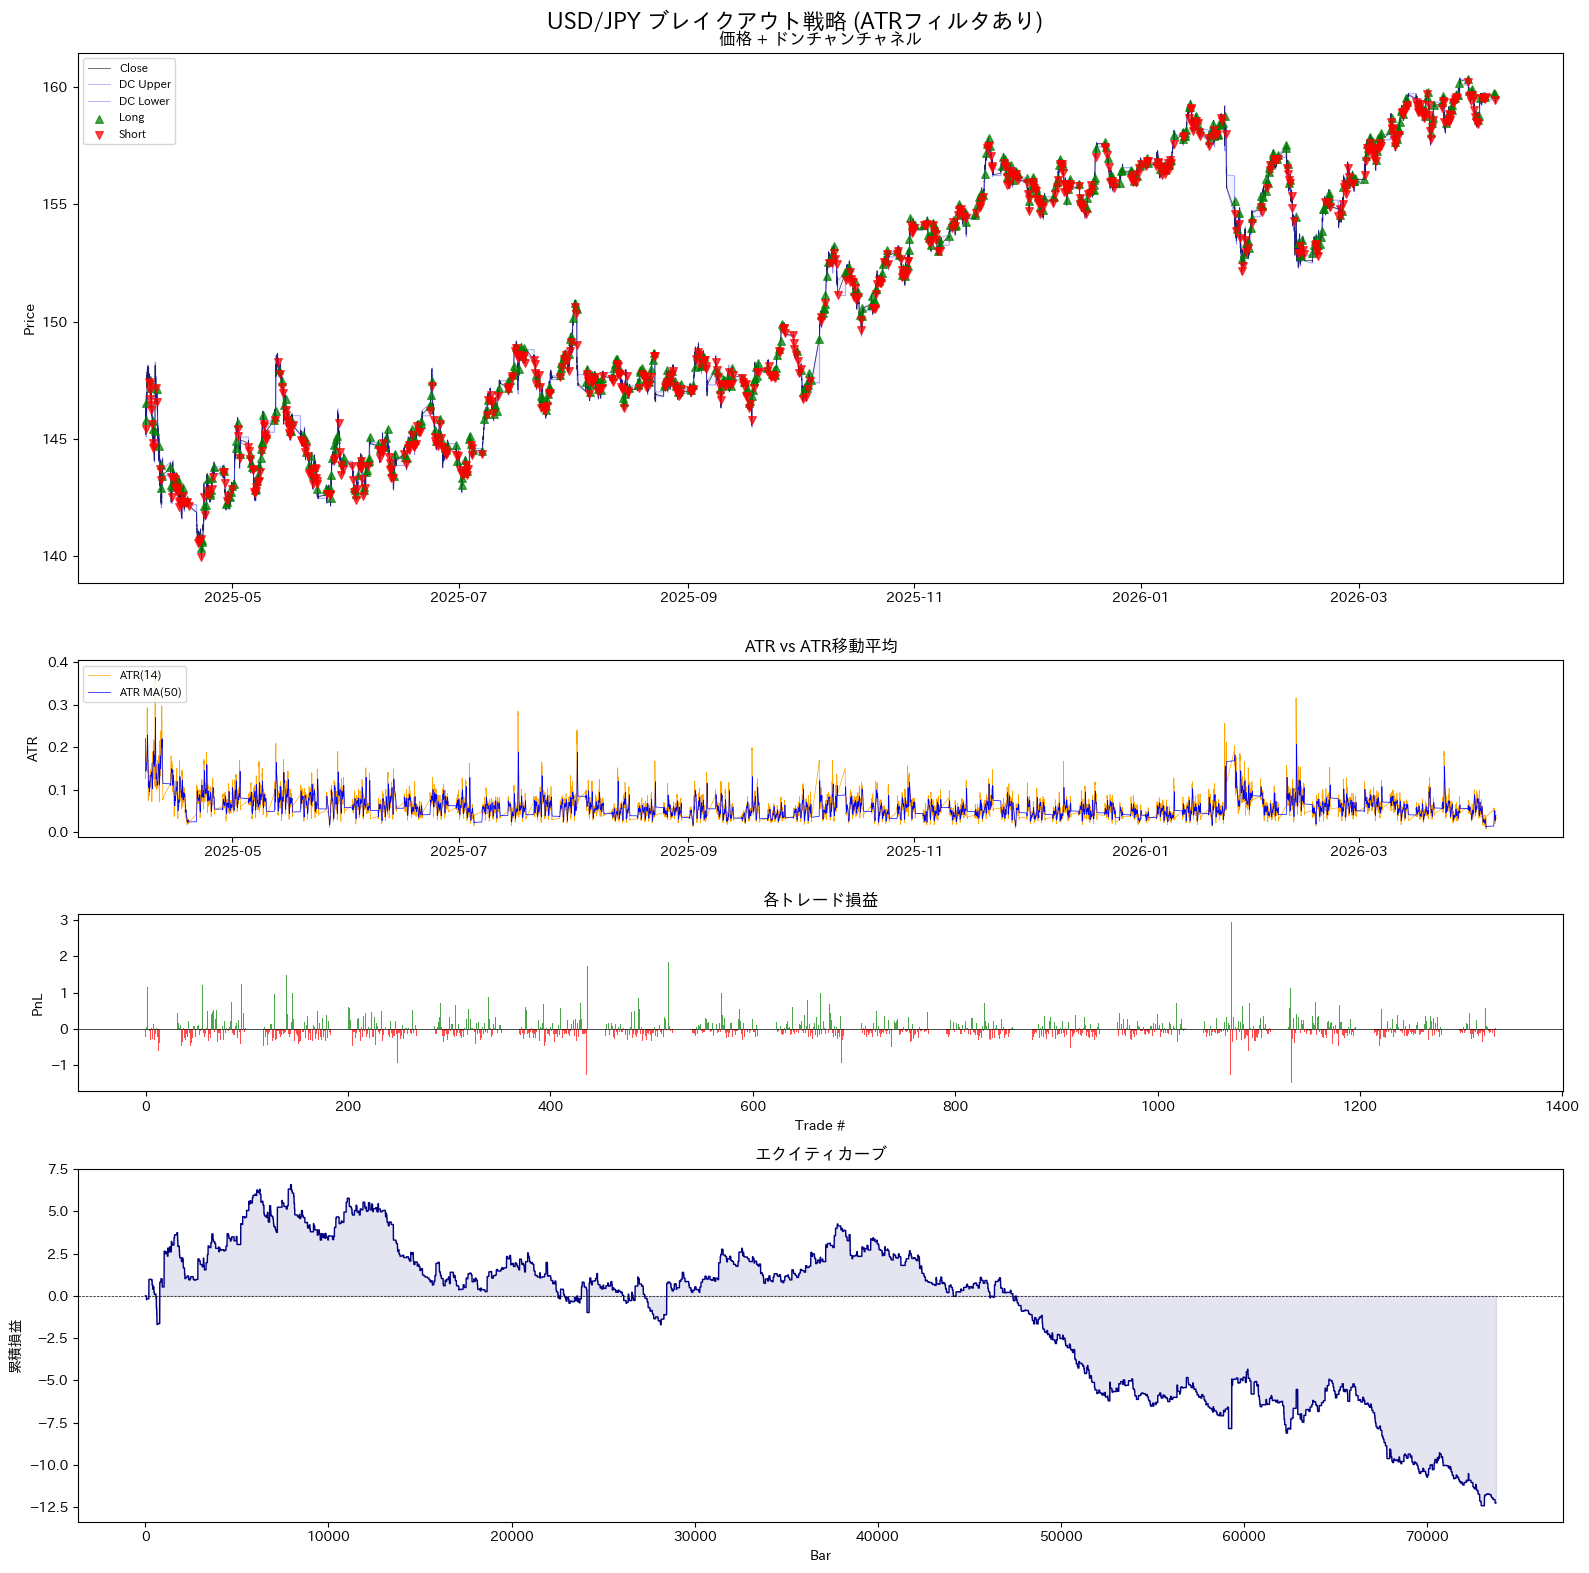

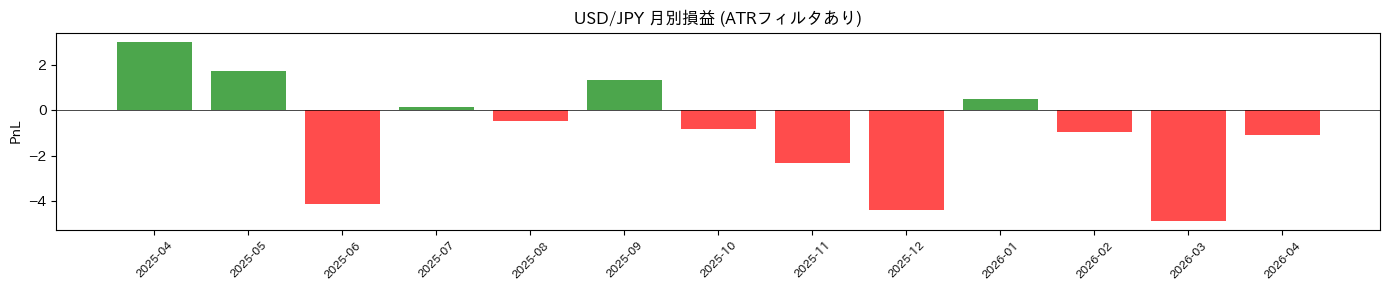

In [11]:
plot_breakout_results(results_usdjpy_atr, df_usdjpy, label="(ATRフィルタあり)")

### ETH/JPY 結果（ATRフィルタあり）

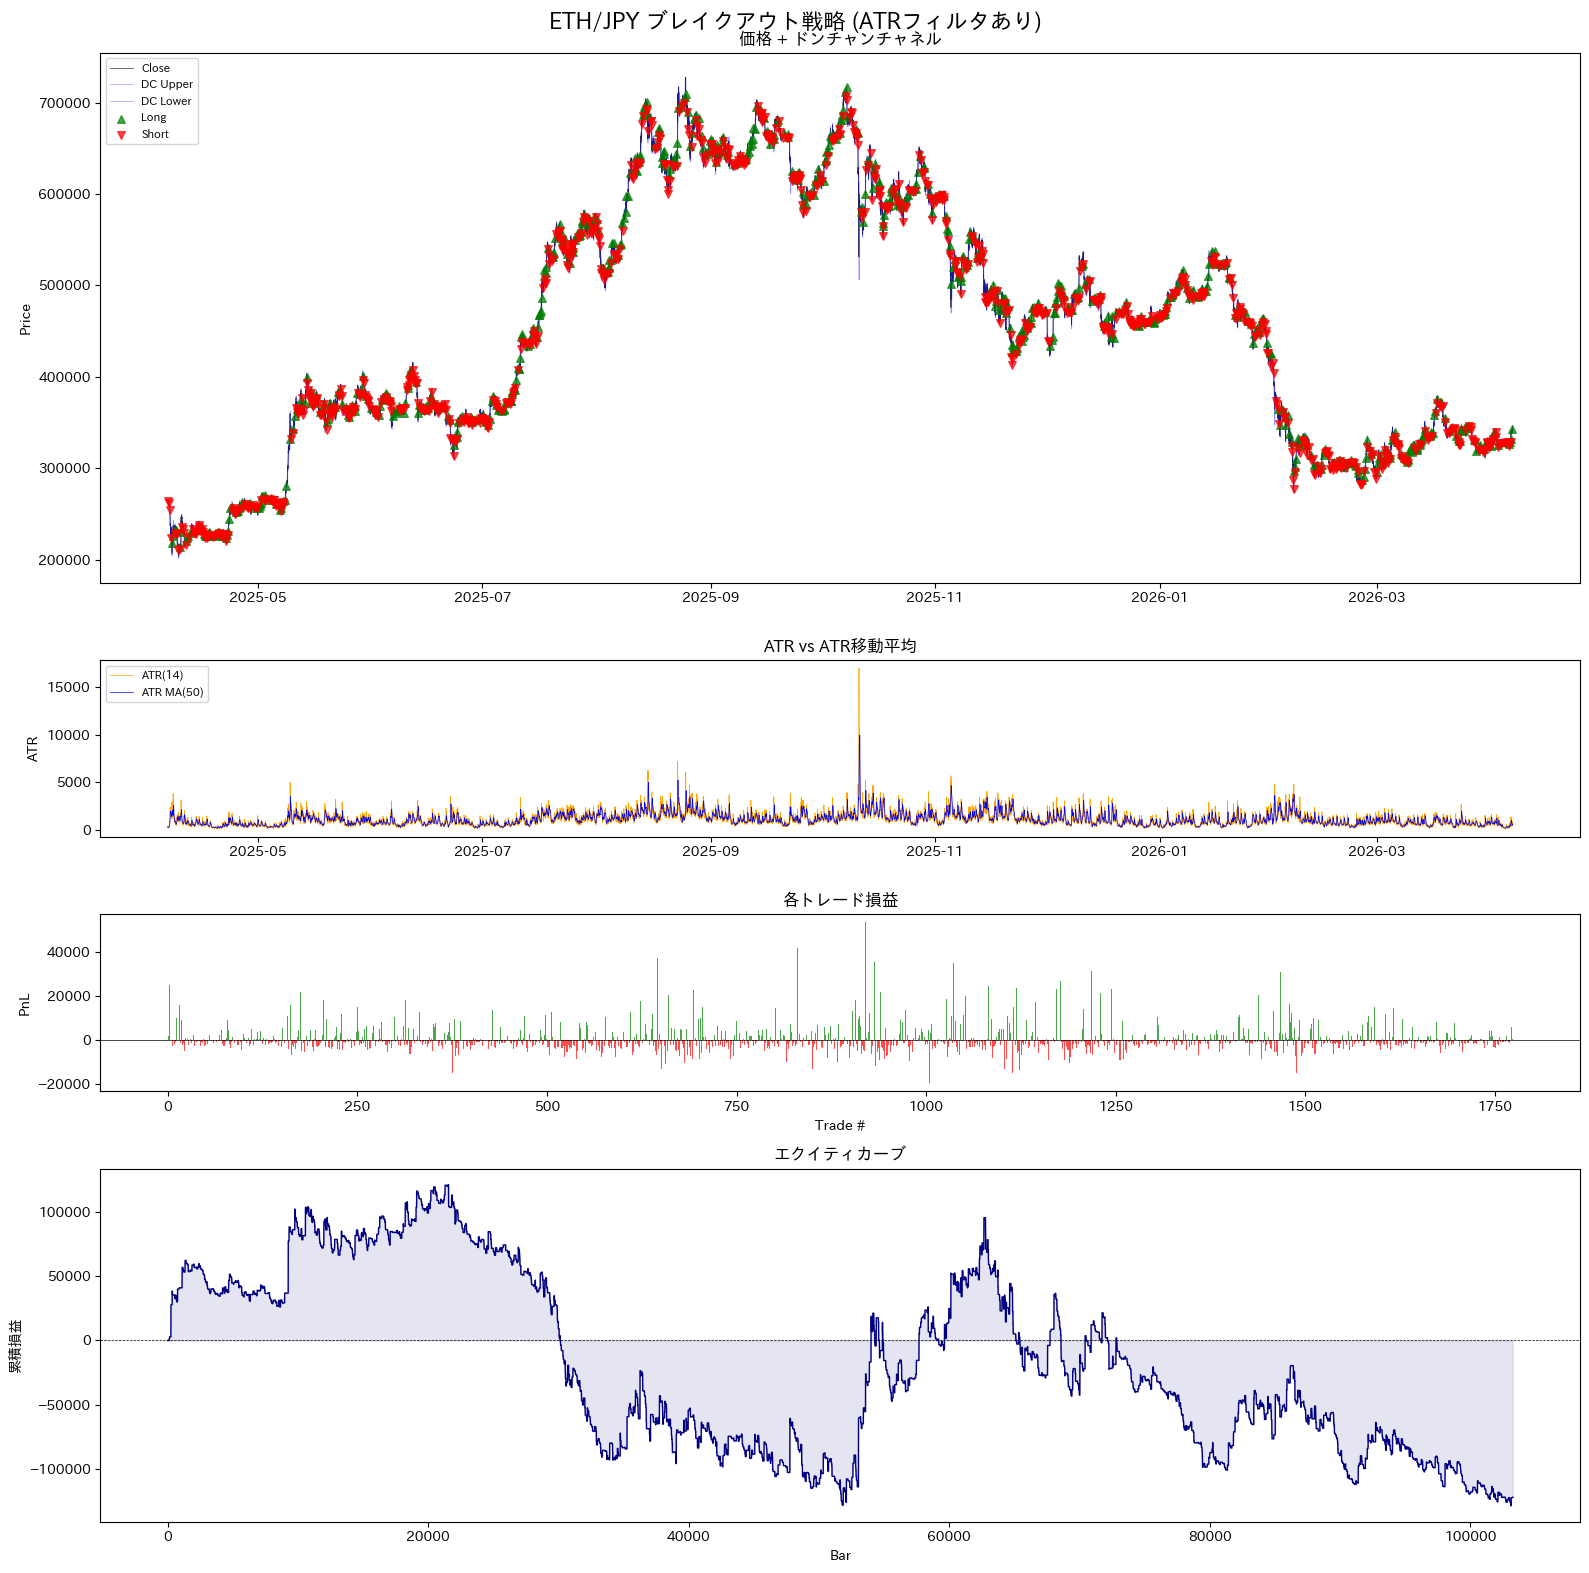

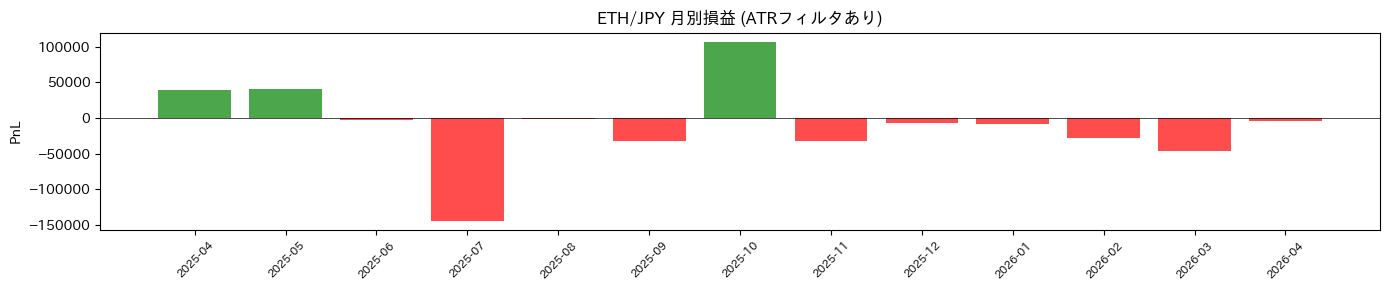

In [12]:
plot_breakout_results(results_eth_atr, df_eth, label="(ATRフィルタあり)")

## 6. パラメータ感度分析

In [13]:
def breakout_sensitivity(df, symbol_name, spread):
    """ドンチャン期間 x ATR期間 x ATR MA期間 の感度分析"""
    rows = []
    dc_periods  = [10, 15, 20, 30, 40]
    atr_periods = [10, 14, 20]
    atr_ma_periods = [30, 50, 80]
    total = len(dc_periods) * len(atr_periods) * len(atr_ma_periods)

    print(f"{symbol_name} 感度分析中... ({total}パターン)")

    for dc_p in dc_periods:
        for atr_p in atr_periods:
            for atr_ma_p in atr_ma_periods:
                tmp = df.copy()
                tmp["atr"] = calc_atr(tmp, period=atr_p)
                tmp["atr_ma"] = tmp["atr"].rolling(window=atr_ma_p).mean()
                tmp["dc_upper"], tmp["dc_lower"] = calc_donchian(tmp, period=dc_p)
                exit_p = max(dc_p // 2, 5)
                tmp["dc_exit_upper"] = tmp["high"].rolling(window=exit_p).max()
                tmp["dc_exit_lower"] = tmp["low"].rolling(window=exit_p).min()
                tmp = tmp.dropna().reset_index(drop=True)

                pos = 0; ep = 0.0; pnls = []
                for i in range(1, len(tmp)):
                    c = tmp["close"].iloc[i]
                    prev_u = tmp["dc_upper"].iloc[i-1]
                    prev_l = tmp["dc_lower"].iloc[i-1]
                    atr_v  = tmp["atr"].iloc[i]
                    atr_m  = tmp["atr_ma"].iloc[i]
                    ex_u   = tmp["dc_exit_upper"].iloc[i-1]
                    ex_l   = tmp["dc_exit_lower"].iloc[i-1]

                    if pos == 0:
                        if c > prev_u and atr_v > atr_m:
                            pos = 1; ep = c + spread
                        elif c < prev_l and atr_v > atr_m:
                            pos = -1; ep = c - spread
                    elif pos == 1 and c < ex_l:
                        pnls.append((c - spread) - ep); pos = 0
                    elif pos == -1 and c > ex_u:
                        pnls.append(ep - (c + spread)); pos = 0

                if pnls:
                    arr = np.array(pnls)
                    w = arr[arr > 0]; l = arr[arr <= 0]
                    gp = w.sum() if len(w) else 0
                    gl = abs(l.sum()) if len(l) else 0
                    rows.append({
                        "DC期間": dc_p, "ATR期間": atr_p, "ATR_MA": atr_ma_p,
                        "トレード数": len(pnls),
                        "勝率%": round(len(w)/len(pnls)*100, 1),
                        "総損益": round(arr.sum(), 4),
                        "PF": round(gp/gl, 3) if gl > 0 else 0,
                    })

    grid = pd.DataFrame(rows).sort_values("PF", ascending=False)
    print(f"\n{symbol_name} TOP10 (PF順):")
    display(grid.head(10))

    filtered = grid[grid["トレード数"] >= 10].copy()
    if len(filtered):
        print(f"\n{symbol_name} TOP10 (トレード数>=10, PF順):")
        display(filtered.head(10))
    return grid

print("感度分析関数を定義")

感度分析関数を定義


### USD/JPY 感度分析

In [14]:
grid_usdjpy = breakout_sensitivity(df_usdjpy, "USD/JPY", spread=0.002)

USD/JPY 感度分析中... (45パターン)

USD/JPY TOP10 (PF順):


,DC期間,ATR期間,ATR_MA,トレード数,勝率%,総損益,PF
44,40,20,80,793,37.8,4.316,1.046
40,40,14,50,872,37.8,3.974,1.038
41,40,14,80,819,38.2,3.249,1.033
38,40,10,80,856,38.0,2.851,1.028
36,40,10,30,958,36.1,2.569,1.022
43,40,20,50,844,38.3,2.068,1.020
42,40,20,30,895,37.2,0.675,1.006
37,40,10,50,908,37.1,0.496,1.004
39,40,14,30,930,36.5,0.149,1.001
27,30,10,30,1140,36.8,-0.735,0.994



USD/JPY TOP10 (トレード数>=10, PF順):


,DC期間,ATR期間,ATR_MA,トレード数,勝率%,総損益,PF
44,40,20,80,793,37.8,4.316,1.046
40,40,14,50,872,37.8,3.974,1.038
41,40,14,80,819,38.2,3.249,1.033
38,40,10,80,856,38.0,2.851,1.028
36,40,10,30,958,36.1,2.569,1.022
43,40,20,50,844,38.3,2.068,1.020
42,40,20,30,895,37.2,0.675,1.006
37,40,10,50,908,37.1,0.496,1.004
39,40,14,30,930,36.5,0.149,1.001
27,30,10,30,1140,36.8,-0.735,0.994


### ETH/JPY 感度分析

In [15]:
eth_spread = df_eth["close"].mean() * 0.00005
grid_eth = breakout_sensitivity(df_eth, "ETH/JPY", spread=eth_spread)

ETH/JPY 感度分析中... (45パターン)

ETH/JPY TOP10 (PF順):


,DC期間,ATR期間,ATR_MA,トレード数,勝率%,総損益,PF
43,40,20,50,1094,34.9,235865.2085,1.092
40,40,14,50,1164,34.5,189492.4997,1.071
39,40,14,30,1292,34.7,206691.4894,1.071
44,40,20,80,1024,34.7,172564.9173,1.070
42,40,20,30,1219,34.7,174061.3000,1.062
38,40,10,80,1152,35.0,167772.9069,1.062
34,30,20,50,1296,35.0,152412.0203,1.054
37,40,10,50,1236,34.5,149930.0564,1.052
41,40,14,80,1091,34.9,125374.3103,1.048
36,40,10,30,1364,34.3,68129.0461,1.022



ETH/JPY TOP10 (トレード数>=10, PF順):


,DC期間,ATR期間,ATR_MA,トレード数,勝率%,総損益,PF
43,40,20,50,1094,34.9,235865.2085,1.092
40,40,14,50,1164,34.5,189492.4997,1.071
39,40,14,30,1292,34.7,206691.4894,1.071
44,40,20,80,1024,34.7,172564.9173,1.070
42,40,20,30,1219,34.7,174061.3000,1.062
38,40,10,80,1152,35.0,167772.9069,1.062
34,30,20,50,1296,35.0,152412.0203,1.054
37,40,10,50,1236,34.5,149930.0564,1.052
41,40,14,80,1091,34.9,125374.3103,1.048
36,40,10,30,1364,34.3,68129.0461,1.022


## 7. ATRフィルタの効果検証 + 比較サマリー

In [16]:
# === ATRフィルタの効果 + デフォルト vs 感度分析TOP の比較 ===

def get_best_params(grid, min_trades=10):
    filtered = grid[grid["トレード数"] >= min_trades]
    if len(filtered) == 0:
        return None
    return filtered.iloc[0]

best_usdjpy = get_best_params(grid_usdjpy)
best_eth    = get_best_params(grid_eth)

rows = []

# USD/JPY
rows.append({
    "通貨ペア": "USD/JPY", "条件": "ATRフィルタなし (DC20)",
    "トレード数": results_usdjpy_noatr["total_trades"],
    "勝率%": round(results_usdjpy_noatr["win_rate"], 1),
    "総損益": round(results_usdjpy_noatr["total_pnl"], 4),
    "PF": round(results_usdjpy_noatr["profit_factor"], 3),
})
rows.append({
    "通貨ペア": "USD/JPY", "条件": "ATRフィルタあり (DC20)",
    "トレード数": results_usdjpy_atr["total_trades"],
    "勝率%": round(results_usdjpy_atr["win_rate"], 1),
    "総損益": round(results_usdjpy_atr["total_pnl"], 4),
    "PF": round(results_usdjpy_atr["profit_factor"], 3),
})
if best_usdjpy is not None:
    rows.append({
        "通貨ペア": "USD/JPY",
        "条件": f"感度分析TOP (DC{best_usdjpy['DC期間']}, ATR{best_usdjpy['ATR期間']}, MA{best_usdjpy['ATR_MA']})",
        "トレード数": best_usdjpy["トレード数"],
        "勝率%": best_usdjpy["勝率%"],
        "総損益": best_usdjpy["総損益"],
        "PF": best_usdjpy["PF"],
    })

# ETH/JPY
rows.append({
    "通貨ペア": "ETH/JPY", "条件": "ATRフィルタなし (DC20)",
    "トレード数": results_eth_noatr["total_trades"],
    "勝率%": round(results_eth_noatr["win_rate"], 1),
    "総損益": round(results_eth_noatr["total_pnl"], 4),
    "PF": round(results_eth_noatr["profit_factor"], 3),
})
rows.append({
    "通貨ペア": "ETH/JPY", "条件": "ATRフィルタあり (DC20)",
    "トレード数": results_eth_atr["total_trades"],
    "勝率%": round(results_eth_atr["win_rate"], 1),
    "総損益": round(results_eth_atr["total_pnl"], 4),
    "PF": round(results_eth_atr["profit_factor"], 3),
})
if best_eth is not None:
    rows.append({
        "通貨ペア": "ETH/JPY",
        "条件": f"感度分析TOP (DC{best_eth['DC期間']}, ATR{best_eth['ATR期間']}, MA{best_eth['ATR_MA']})",
        "トレード数": best_eth["トレード数"],
        "勝率%": best_eth["勝率%"],
        "総損益": best_eth["総損益"],
        "PF": best_eth["PF"],
    })

print("=" * 70)
print("ブレイクアウト戦略 最終比較（5分足）")
print("  ATRフィルタなし vs あり vs 感度分析ベスト（トレード数>=10）")
print("=" * 70)
display(pd.DataFrame(rows))
print()
print("* 感度分析の最適化パラメータはin-sampleの結果。")

ブレイクアウト戦略 最終比較（5分足）
  ATRフィルタなし vs あり vs 感度分析ベスト（トレード数>=10）


,通貨ペア,条件,トレード数,勝率%,総損益,PF
0,USD/JPY,ATRフィルタなし (DC20),2171.0,34.8,-19.5330,0.895
1,USD/JPY,ATRフィルタあり (DC20),1335.0,38.1,-12.2350,0.906
2,USD/JPY,"感度分析TOP (DC40.0, ATR20.0, MA80.0)",793.0,37.8,4.3160,1.046
3,ETH/JPY,ATRフィルタなし (DC20),3074.0,33.1,-418916.9827,0.911
4,ETH/JPY,ATRフィルタあり (DC20),1774.0,34.0,-122120.5339,0.962
5,ETH/JPY,"感度分析TOP (DC40.0, ATR20.0, MA50.0)",1094.0,34.9,235865.2085,1.092



* 感度分析の最適化パラメータはin-sampleの結果。
